In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
RANDOM_STATE = 42
DATA_PATH = 'cleaned_dataset.csv'


In [2]:
df = pd.read_csv(DATA_PATH)

excluded_columns = {'Ticker', 'Sector', 'Stock_Return', 'Class', 'Year', 'Return_Direction'}
feature_columns = [col for col in df.columns if col not in excluded_columns]

y_direction = (df['Stock_Return'] > 0).astype(int)
if 'Return_Direction' in df.columns:
    assert (y_direction == df['Return_Direction']).all(), 'Return_Direction does not match Stock_Return > 0.'

train_mask = df['Year'].between(2014, 2017)
test_mask = df['Year'] == 2018

X_train = df.loc[train_mask, feature_columns].copy()
X_test = df.loc[test_mask, feature_columns].copy()
y_train = y_direction.loc[train_mask].copy()
y_test = y_direction.loc[test_mask].copy()
train_years = df.loc[train_mask, 'Year'].reset_index(drop=True)

print(f'Total observations: {df.shape[0]:,}')
print(f'Number of features used: {len(feature_columns)}')
print(f'Training rows (feature years 2014-2017): {len(X_train):,}')
print(f'Test rows (feature year 2018): {len(X_test):,}')
print(f'Missing values in selected features: {df[feature_columns].isna().sum().sum():,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test positive rate: {y_test.mean():.3f}')


Total observations: 22,031
Number of features used: 201
Training rows (feature years 2014-2017): 17,641
Test rows (feature year 2018): 4,390
Missing values in selected features: 0
Train positive rate: 0.513
Test positive rate: 0.692


In [3]:
def make_expanding_year_splits(year_series: pd.Series):
    unique_years = sorted(year_series.unique())
    splits = []

    for index in range(1, len(unique_years)):
        train_year_subset = unique_years[:index]
        validation_year = unique_years[index]

        train_idx = np.where(year_series.isin(train_year_subset))[0]
        validation_idx = np.where(year_series == validation_year)[0]
        splits.append((train_idx, validation_idx))

    return splits


cv_splits = make_expanding_year_splits(train_years)
[(len(train_idx), len(val_idx)) for train_idx, val_idx in cv_splits]


[(3787, 4114), (7901, 4783), (12684, 4957)]

In [4]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    param_grid,
    cv=cv_splits,
    scoring='f1_macro',
    refit=False,
    verbose=1,
)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')
display_cols = [
    'param_n_estimators', 'param_max_depth', 'param_min_samples_split',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
cv_top = cv_results[display_cols].head(10).copy()
cv_top = cv_top.rename(columns={'mean_test_score': 'cv_macro_f1', 'std_test_score': 'cv_macro_f1_std'})
print('Top 10 configurations by CV macro F1:')
display(cv_top)

best_params = grid_search.best_params_.copy()
print(f'\nBest configuration: {best_params}')
print(f'Best CV macro F1: {grid_search.best_score_:.4f}')


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Top 10 configurations by CV macro F1:


,param_n_estimators,param_max_depth,param_min_samples_split,cv_macro_f1,cv_macro_f1_std,rank_test_score
3,300,5,5,0.510022,0.068481,1
5,300,5,10,0.509125,0.067728,2
2,100,5,5,0.508698,0.071342,3
4,100,5,10,0.507895,0.068429,4
1,300,5,2,0.507809,0.067297,5
0,100,5,2,0.506562,0.068050,6
9,300,10,5,0.502530,0.063507,7
11,300,10,10,0.499958,0.063844,8
10,100,10,10,0.499009,0.061982,9
7,300,10,2,0.498969,0.066339,10



Best configuration: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV macro F1: 0.5100


In [5]:
best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
best_rf.fit(X_train, y_train)

rf_pred = best_rf.predict(X_test)
rf_prob_positive = best_rf.predict_proba(X_test)[:, 1]

rf_results = pd.Series({
    'accuracy': accuracy_score(y_test, rf_pred),
    'roc_auc': roc_auc_score(y_test, rf_prob_positive),
    'precision_macro': precision_score(y_test, rf_pred, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, rf_pred, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test, rf_pred, average='macro', zero_division=0),
}, name='Random Forest')

print('Best hyperparameters:')
print(best_params)
print()
print(rf_results.round(4))


Best hyperparameters:
{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}

accuracy           0.6825
roc_auc            0.7225
precision_macro    0.6435
recall_macro       0.6578
f1_macro           0.6471
Name: Random Forest, dtype: float64


In [6]:
baseline_models = {
    'Majority Class': DummyClassifier(strategy='most_frequent'),
    'Stratified Random': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
}

baseline_rows = []
for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    baseline_pred = model.predict(X_test)
    baseline_prob = model.predict_proba(X_test)[:, 1]

    baseline_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, baseline_pred),
        'roc_auc': roc_auc_score(y_test, baseline_prob),
        'precision_macro': precision_score(y_test, baseline_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, baseline_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, baseline_pred, average='macro', zero_division=0),
    })

results_table = pd.concat([
    pd.DataFrame(baseline_rows).set_index('model'),
    rf_results.to_frame().T,
]).round(4)

results_table


,accuracy,roc_auc,precision_macro,recall_macro,f1_macro
Majority Class,0.6918,0.5000,0.3459,0.5000,0.4089
Stratified Random,0.4973,0.4914,0.4926,0.4914,0.4755
Random Forest,0.6825,0.7225,0.6435,0.6578,0.6471


                 precision    recall  f1-score   support

Negative return       0.49      0.59      0.54      1353
Positive return       0.80      0.72      0.76      3037

       accuracy                           0.68      4390
      macro avg       0.64      0.66      0.65      4390
   weighted avg       0.70      0.68      0.69      4390



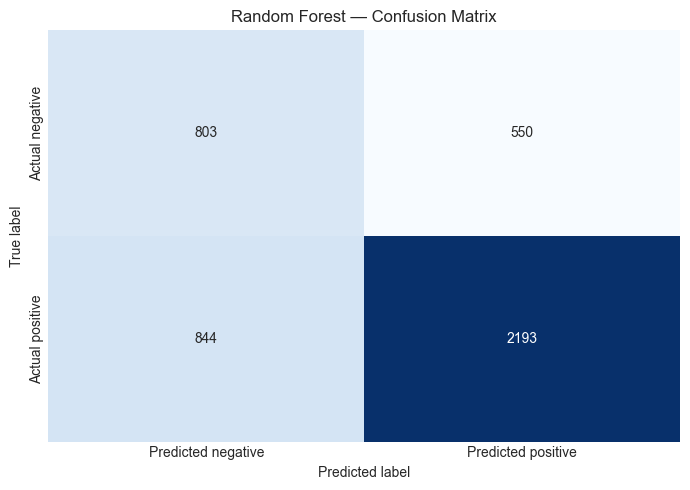

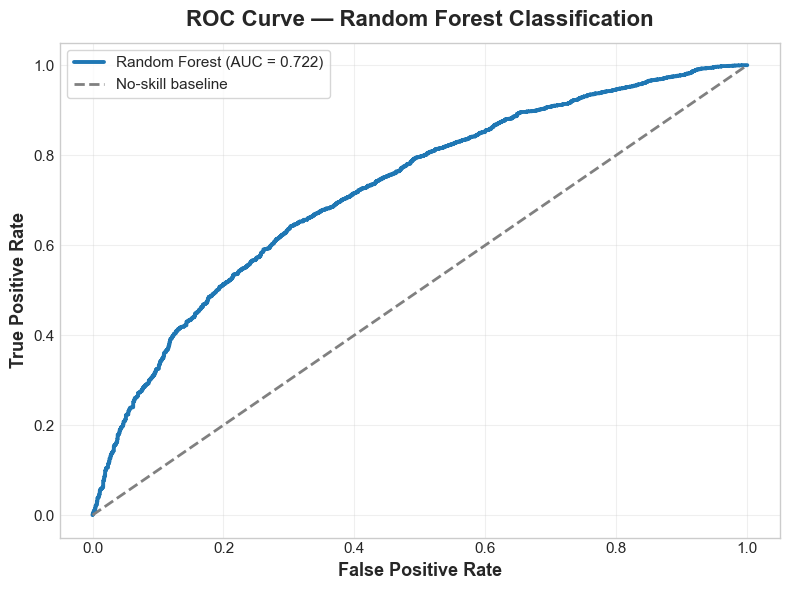

In [7]:
print(classification_report(y_test, rf_pred, target_names=['Negative return', 'Positive return'], zero_division=0))

cm = confusion_matrix(y_test, rf_pred)
cm_df = pd.DataFrame(cm, index=['Actual negative', 'Actual positive'], columns=['Predicted negative', 'Predicted positive'])
cm_df

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Random Forest — Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, rf_prob_positive)
rf_auc = roc_auc_score(y_test, rf_prob_positive)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    fpr,
    tpr,
    color='#1f77b4',
    linewidth=2.8,
    label=f'Random Forest (AUC = {rf_auc:.3f})',
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    linewidth=2,
    label='No-skill baseline',
)
ax.set_title('ROC Curve — Random Forest Classification', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(loc='upper left', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_roc.png', dpi=300, bbox_inches='tight')
plt.show()


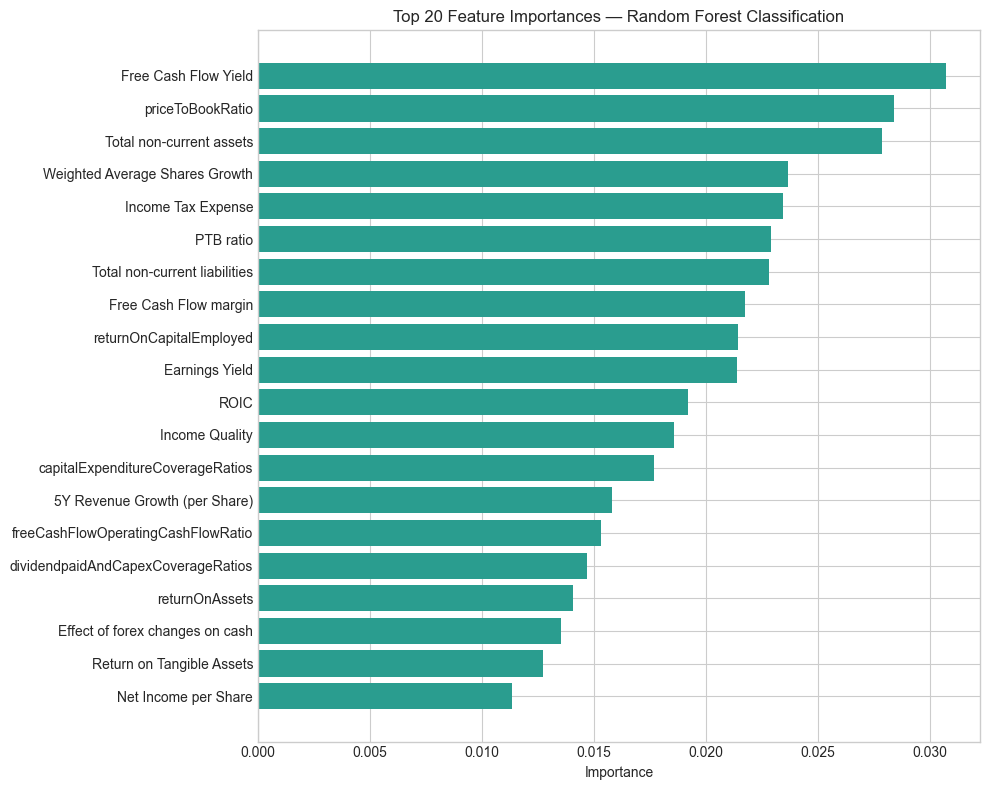

,importance
Free Cash Flow Yield,0.030713
priceToBookRatio,0.028390
Total non-current assets,0.027881
Weighted Average Shares Growth,0.023667
Income Tax Expense,0.023460
PTB ratio,0.022910
Total non-current liabilities,0.022803
Free Cash Flow margin,0.021753
returnOnCapitalEmployed,0.021437
Earnings Yield,0.021372


In [8]:
feature_importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

top_features = feature_importances.head(20).sort_values()

plt.figure(figsize=(10, 8))
plt.barh(top_features.index, top_features.values, color='#2a9d8f')
plt.title('Top 20 Feature Importances — Random Forest Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features.to_frame('importance').sort_values('importance', ascending=False)
